# Projet Python de Clémentine, Louise et Hugo
Notre sujet s'intéresse à la question suivante : 
**Quel sont les déterminants de la fréquentation du réseau STAR à Rennes en 2025** ? 
En particulier, dans quelle mesure la **météo** et les **prix du carburant** influencent-ils l’usage de ce réseau de transports en commun ?


Nous utlisons pour cela trois sources de données : 
- **Données de fréquentation du réseau STAR sur l'année 2025**, détaillée quotidiennement pour chaque type de ligne ou de moyens du réseau (bus, métro, parking relais,...). Ces données sont disponibles via téléchargement direct (csv) ou par requête API. 
Nous avions débuté par une récupération de ces données par API mais nous avons été rapidement bloqués dans notre progression. Ainsi, le service était bloqué par l'administrateur STAR du fait du nombre important de requêtes. C'est pourquoi nous sommes passés à une récupération directe par csv. 
- **Données de météo, en API**. Nous nous intéressons particulièrement aux données de température et métriques de précipitatins quoitidiennes pour Rennes. 
- **Données de carburant**, téléchargées en archives zippées sur data.gouv 

*Lien vers les données star : https://data.explore.star.fr/explore/dataset/tco-billettique-star-frequentation-agregee-td/table/?dataChart=eyJxdWVyaWVzIjpbeyJjaGFydHMiOlt7ImFsaWduTW9udGgiOnRydWUsInR5cGUiOiJjb2x1bW4iLCJmdW5jIjoiU1VNIiwieUF4aXMiOiJmcmVxdWVudGF0aW9uIiwic2NpZW50aWZpY0Rpc3BsYXkiOnRydWUsImNvbG9yIjoicmFuZ2UtU2V0MSJ9XSwieEF4aXMiOiJkYXRlIiwibWF4cG9pbnRzIjoiIiwidGltZXNjYWxlIjoiZGF5Iiwic29ydCI6IiIsInNlcmllc0JyZWFrZG93blRpbWVzY2FsZSI6IiIsInNlcmllc0JyZWFrZG93biI6ImNhdGVnb3JpZWxpZ25lIiwic3RhY2tlZCI6Im5vcm1hbCIsImNvbmZpZyI6eyJkYXRhc2V0IjoidGNvLWJpbGxldHRpcXVlLXN0YXItZnJlcXVlbnRhdGlvbi1hZ3JlZ2VlLXRkIiwib3B0aW9ucyI6e319fV0sImRpc3BsYXlMZWdlbmQiOnRydWUsImFsaWduTW9udGgiOnRydWV9*


*Lien vers l'API météo : https://archive-api.open-meteo.com/v1/archive*

*Lien vers les données de carburant : https://www.prix-carburants.gouv.fr/rubrique/opendata/ et https://donnees.roulez-eco.fr/opendata/annee/2025 pour le téléchargement direct du zip pour 2025*

# Partie 1 : Récupération des données

Pour chaque source de données, nous avons codé une fonction de chargement (à retrouver dans src), qui donne un dataframe avec en ligne les différents jours de l'année (1 ligne par jour) et en colonne les variables d'intérêt. 
Puis nous avons merge les 3 dataframes obtenus pour ainsi avoir notre dataframe final, que nous utilisons tout au long de nos analyses.

**Construction du dataframe final** 

*Remarque : la cellule s'exécute généralement en 30 à 40 secondes*

In [1]:
from src.merge import build_dataset

df = build_dataset()

df.head()

Téléchargement des données carburant 2025...
Série quotidienne : 365 jours couverts
Carburants disponibles : ['E10', 'E85', 'GPLc', 'Gazole', 'SP95', 'SP98']


,date,frequentation_metro,frequentation_bus,frequentation_pr,temperature,precipitation,E10,E85,GPLc,Gazole,SP95,SP98
0,2025-01-01,67765.61347,12278.82352,789.47368,10.075000,0.3,1.705375,0.754333,0.921250,1.648750,NaN,1.807500
1,2025-01-02,136025.23386,47476.47058,3359.07121,6.891667,17.9,1.700889,0.754333,0.916000,1.643889,NaN,1.802778
2,2025-01-03,151349.80001,56222.35293,3741.73375,2.379167,0.0,1.705462,0.788750,0.916000,1.651692,1.740,1.805692
3,2025-01-04,116959.09917,41338.82353,2665.26316,1.620833,9.4,1.721700,0.765750,0.916000,1.668300,NaN,1.817444
4,2025-01-05,69976.20538,17065.88235,602.10526,12.320833,14.5,1.721375,0.764667,0.918667,1.668444,1.747,1.821333


In [2]:
print(df.shape)
print(df.dtypes)


(365, 12)
date                   datetime64[ns]
frequentation_metro           float64
frequentation_bus             float64
frequentation_pr              float64
temperature                   float64
precipitation                 float64
E10                           float64
E85                           float64
GPLc                          float64
Gazole                        float64
SP95                          float64
SP98                          float64
dtype: object


In [3]:
print(df.describe())
print(df.isnull().sum())

                                date  frequentation_metro  frequentation_bus  \
count                            365           365.000000         365.000000   
mean   2025-07-01 23:59:59.999999744        176172.391339       64631.983174   
min              2025-01-01 00:00:00          1820.436100         641.176480   
25%              2025-04-02 00:00:00        123449.018900       45317.647060   
50%              2025-07-02 00:00:00        181607.704040       67849.411760   
75%              2025-10-01 00:00:00        236701.700460       91231.764700   
max              2025-12-31 00:00:00        272300.914350      102116.470590   
std                              NaN         65665.808997       28123.636602   

       frequentation_pr  temperature  precipitation         E10         E85  \
count        362.000000   365.000000     365.000000  365.000000  362.000000   
mean        3241.340848    12.857283       2.432329    1.662758    0.733652   
min           54.736840    -0.683333      

Nous observons quelques **valeurs manquantes** sur les carburants, en particuliers sur le SP95. Cela peut s'expliquer par le fait que le SP95 n'est pas proposé dans toutes les stations rennaises, ce qui donne des valeurs manquantes même en aggrégeant, ou alors cela traduit une rupture des stocks. 
Nous traitons ces valeurs manquantes par **imputation** pour pouvoir continuer nos analyses. 

In [4]:
from src.stat_des import impute_carburant

df = impute_carburant(df)

Valeurs manquantes AVANT imputation :
E10         0
E85         3
GPLc        0
Gazole      0
SP95      265
SP98        0
dtype: int64

Valeurs manquantes APRÈS imputation :
E10       0
E85       0
GPLc      0
Gazole    0
SP95      0
SP98      0
dtype: int64


# Partie 2 : Visualisation

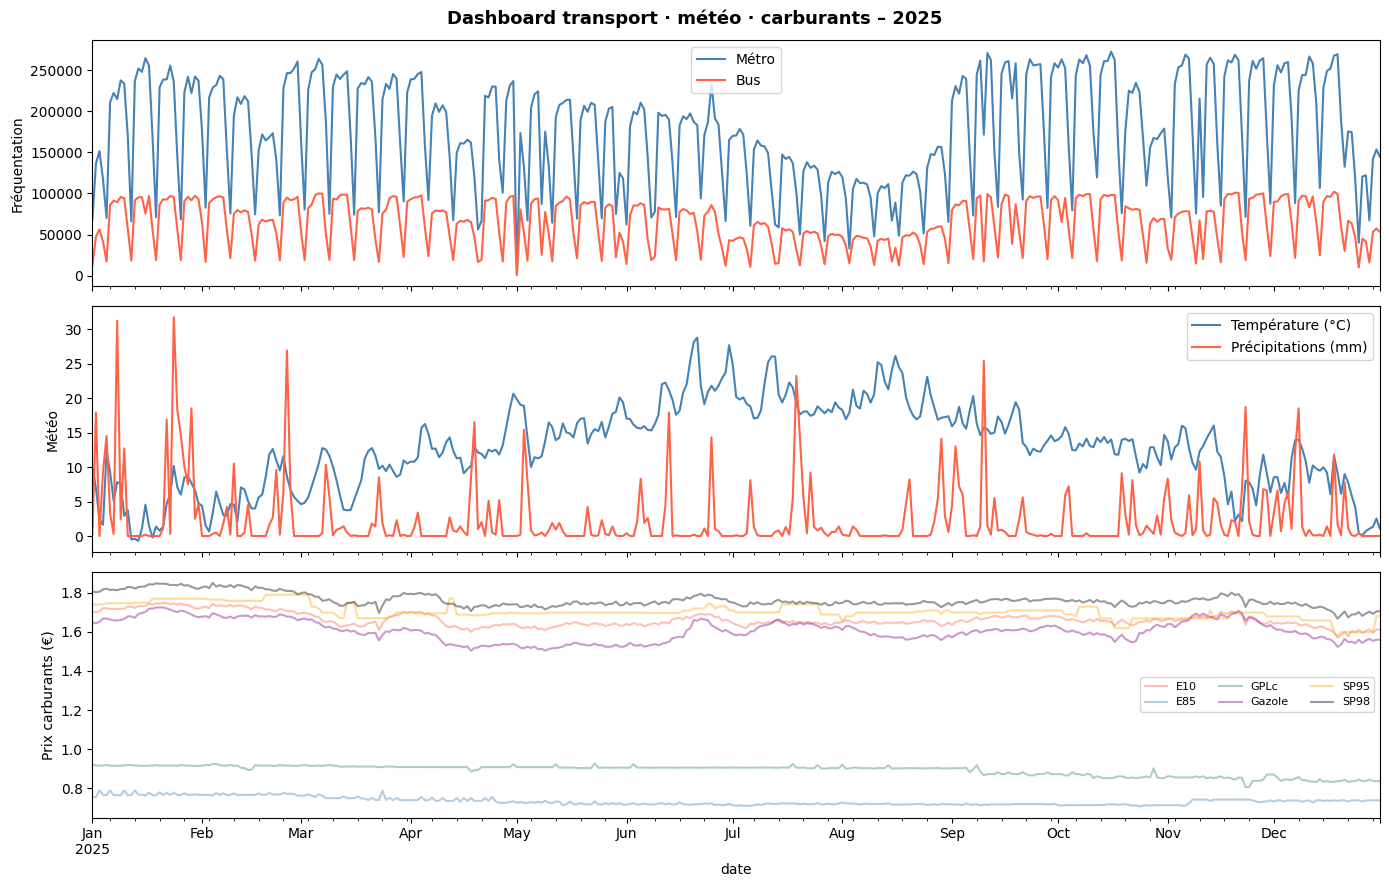

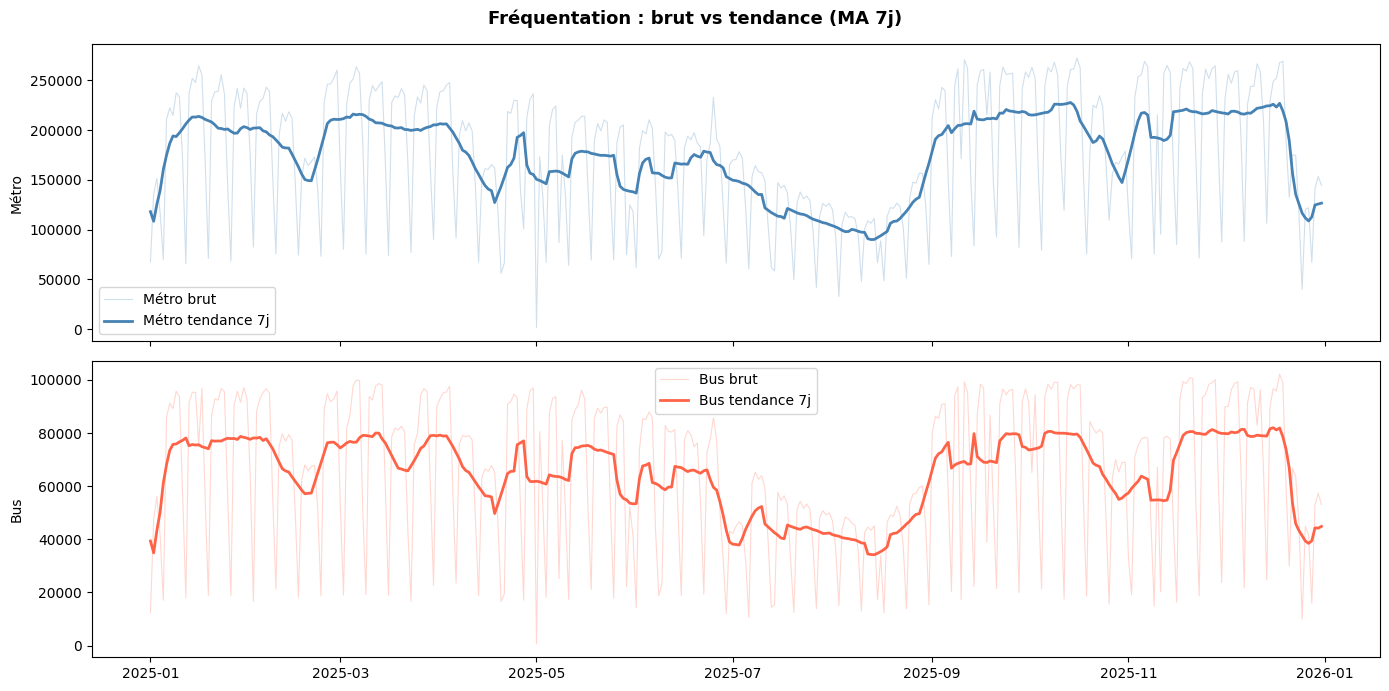

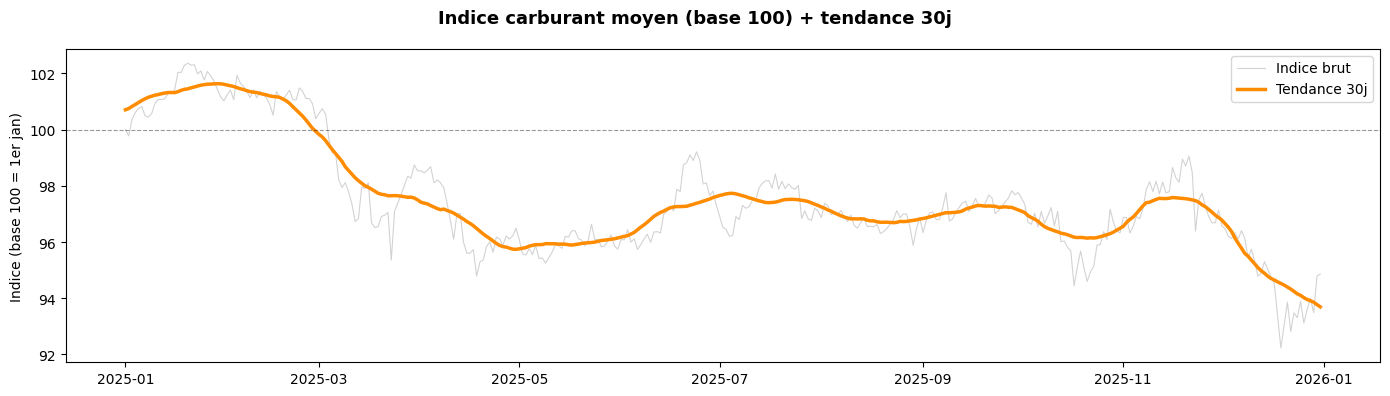

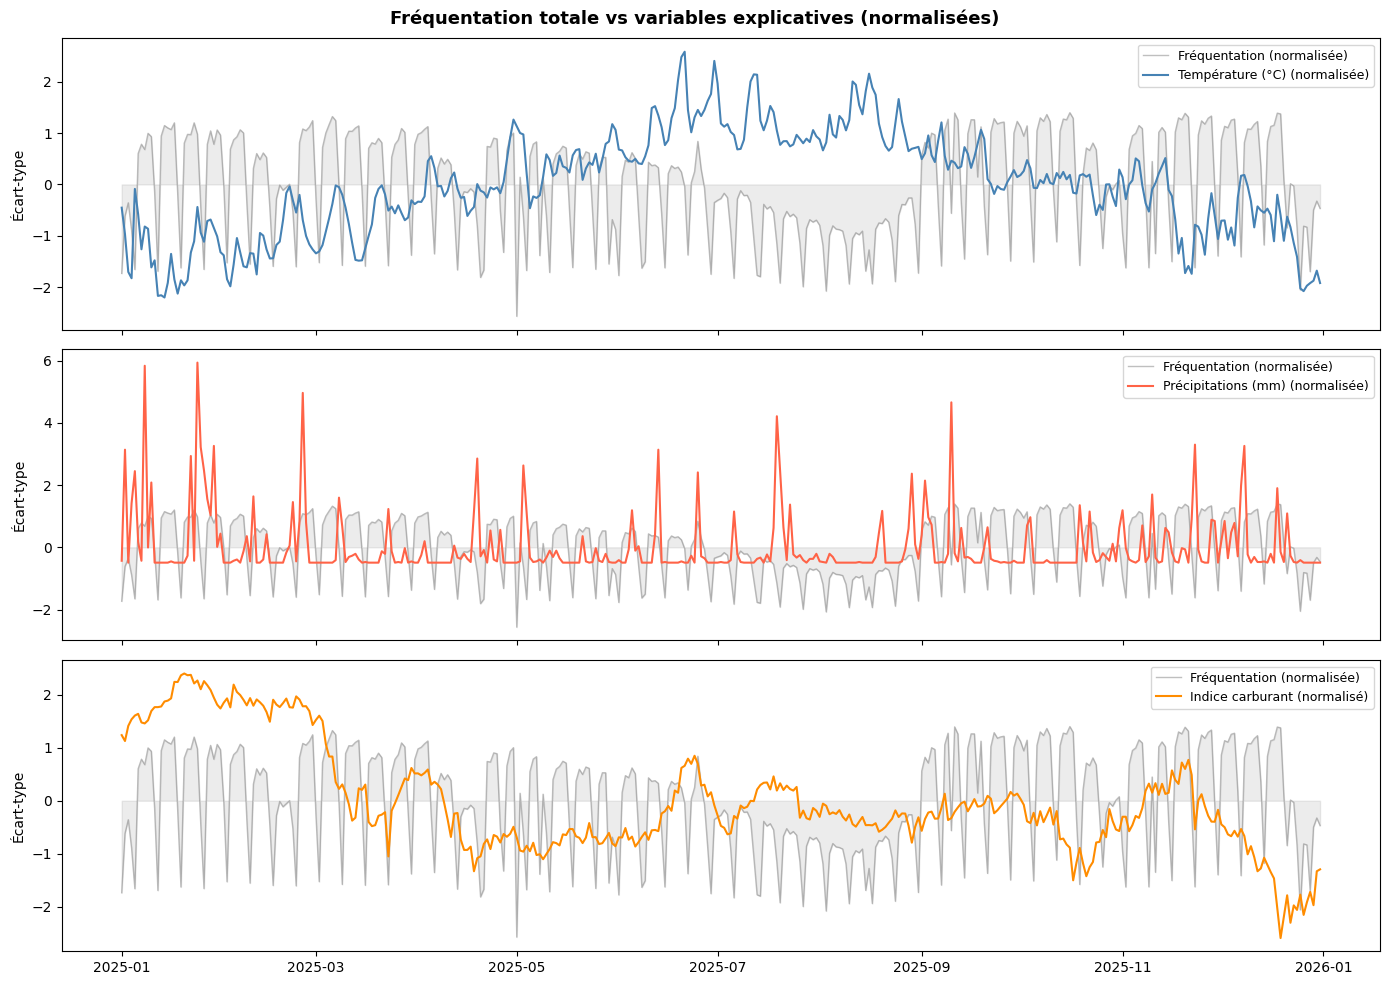

In [5]:
from src.visualisation_avancee import (
    plot_dashboard,
    plot_deseasonalized,
    plot_carburant_index,
    plot_correlation_overview,
)

plot_dashboard(df)              
plot_deseasonalized(df)         
plot_carburant_index(df)        
plot_correlation_overview(df)   

On observe sur le premier graphe une **saisonnalité de la fréquentation du métro et bus sur des périodes hebdomadaires** : la courbe reflète les semaines, avec quand même une **baisse de la fréquentation durant les vacances scolaires**. 
On retrouve cette tendance globale plus clairement sur les graphes désaisonnalisés de l'effet semaine. 

Pour la **météo**, on a une **saisonnalité classique** : températures basses en janvier/février, pic estival juillet/août, puis redescente. Les précipitations sont moins prévisibles mais ont tendance à être plus élevées en automne/hiver (fortes métriques d'octobre à février notamment).
La température est probablement le meilleur signal météo : quand il fait très froid ou très chaud, les gens évitent les transports en commun (voiture, télétravail). La pluie en revanche pousse vers le métro (les gens fuient le vélo/marche). Ces deux variables jouent sur la fréquentation dans des sens différents.

On observe que tout les **carburant évoluent similairement les uns des autres**, dû au fait qu'ils suivent tous le cours du Brent. Ils gardent en moyenne les mêmes écarts sur l'année.

# Partie 3 : Analyse des corrélations

Avant de construire le modèle de régression, on examine les relations linéaires entre les variables explicatives (météo, carburant) et les cibles (fréquentation).  

Deux visualisations complémentaires :
- **Heatmap triangulaire** : vue globale de toutes les corrélations entre variables
- **Bar chart des top corrélations** : zoom sur les variables les plus liées à la fréquentation cible

In [6]:
from src.stat_des import plot_correlation_heatmap, plot_top_correlations

**Heatmap avec toutes les variables**

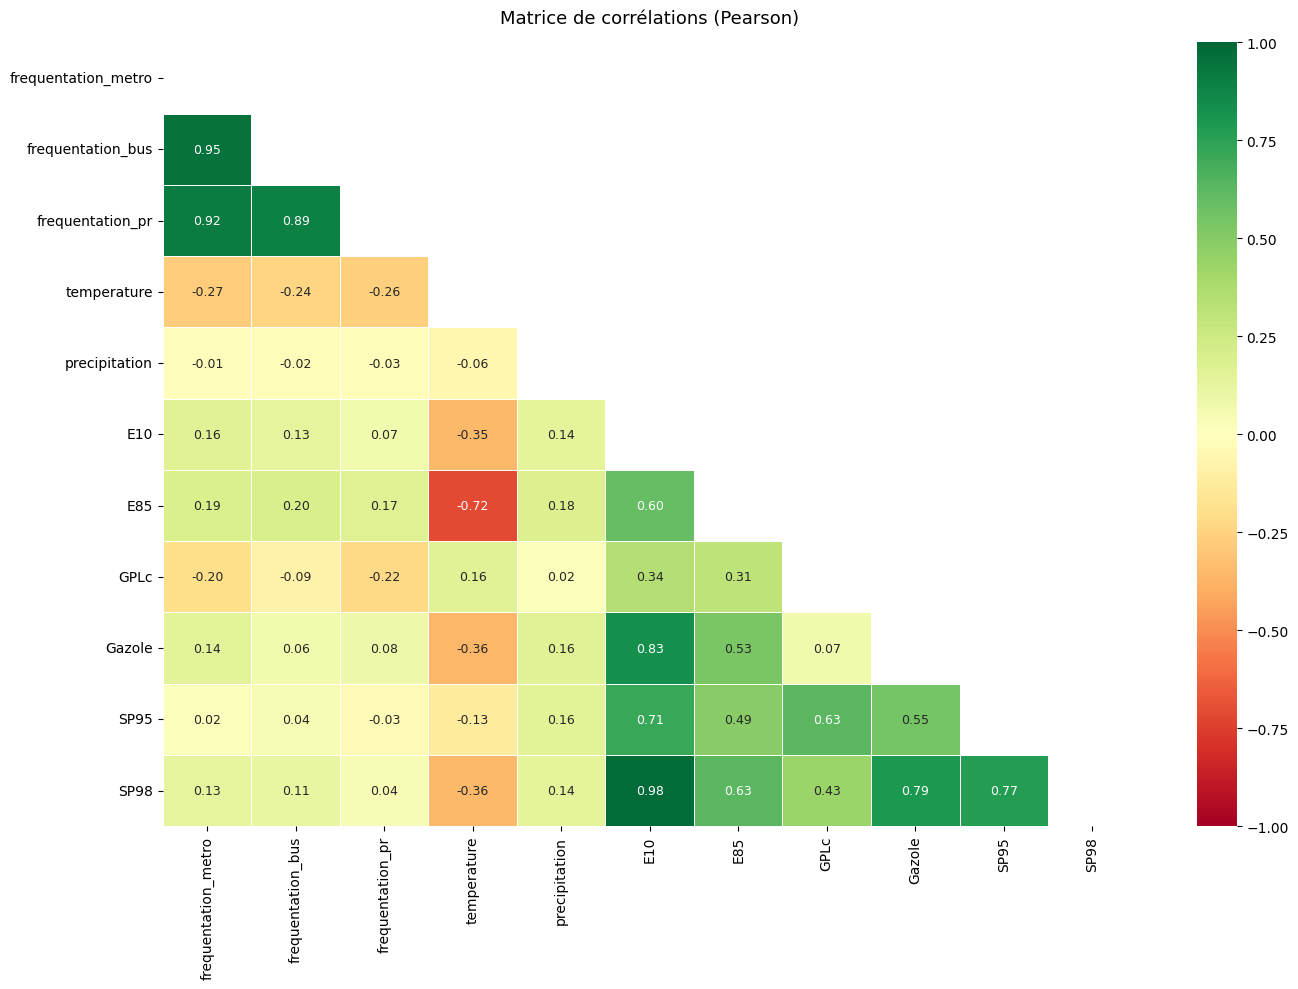

In [7]:
corr = plot_correlation_heatmap(df)

- Les trois **variables de fréquentation** (métro / bus/ parking relais) sont **très fortement corrélées entre elles** (0.89–0.95), ce qui indique qu'elles captent le même phénomène : on peut envisager de les fusionner en une seule variable cible.

- La **température joue négativement** (-0.24 à -0.27) : quand il fait chaud, la fréquentation baisse
(vacances d'été, vélo, marche). Le signal est assez faible mais reste cohérent avec notre première analyse.

- L'influence des **précipitations est quasi nulle** (-0.01 à -0.03) : la pluie n'a pas d'effet mesurable
sur la fréquentation à cette échelle temporelle. On peut donc exclure cette variable du modèle.

- Les **carburants** sont **fortement corrélés entre eux** (E10/SP98 : 0.98, E10/Gazole : 0.83...),
ce qui confirme qu'ils suivent tous le même cours du pétrole. Garder une seule variable carburant suffit. 

L'**E85 fait exception** : corrélation plus faible avec les autres carburants (0.60 avec E10)
et relation bizarre avec la température (-0.72). Cela s'explique par le fait que c'est un carburant au prix subventionné, qui reflète donc une dynamique différente. On peut également l'exclure.

Le **GPLc** se démarque aussi (corrélations plus faibles partout) ; de même, on observe la même logique, du fait d'une niche de marché avec ce carburant.

### Ce qu'on retient pour le modèle
| Variable | Décision |
|---|---|
| `frequentation_metro` + `bus` + `parc_relais` | à fusionner en une seule cible |
| `temperature` | Garder |
| `precipitation` |  Exclure |
| Un seul carburant (ex. `SP98`) |  Garder |
| `E85`, `GPLc` | Exclure ou traiter à part |
| `jour_semaine` | à ajouter (non visible ici mais dominant) |
```

**Top corrélations avec la fréquentation**

On identifie les variables les plus corrélées avec la ligne principale (`frequentation_metro`).  
Changer `target` pour analyser une autre ligne du réseau.

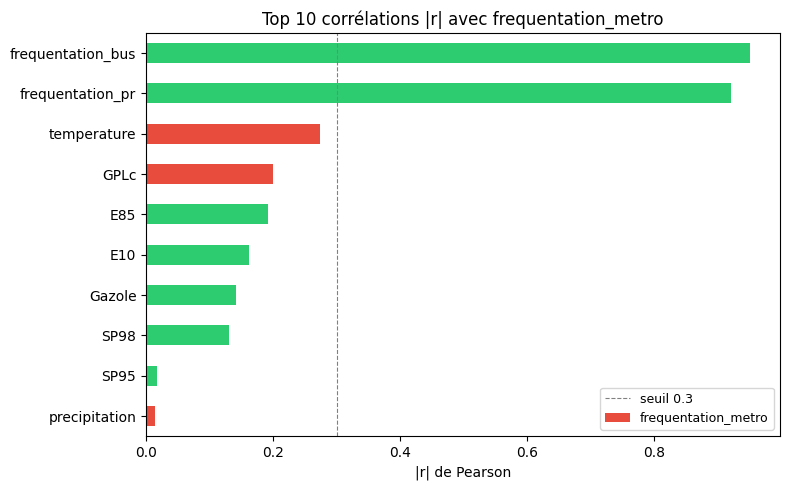


Valeurs complètes (avec signe) pour frequentation_metro :

frequentation_bus    0.951
frequentation_pr     0.921
temperature         -0.274
GPLc                -0.200
E85                  0.192
E10                  0.162
Gazole               0.142
SP98                 0.130
SP95                 0.018
precipitation       -0.014


In [8]:
plot_top_correlations(corr, df, target='frequentation_metro', top_n=10)

**Confirmation du top 10**

Ce graphe confirme les conclusions de la heatmap :
- **`frequentation_bus` et `frequentation_pr`** dominent largement. 
- **`temperature`** est le seul signal externe au-dessus du seuil 0.3. La variable est donc bien à conserver
- **Tous les carburants sont en dessous de 0.3** : un seul suffit, et le signal est assez faible.
- **`precipitation`** a un effet quasi nul.


## Partie 4 : Modélisation 

**Sélection des variables**

Les variables retenues comme features du modèle sont issues de l'analyse exploratoire menée en partie 3.
La matrice de corrélations et le graphe des corrélations nous ont ainsi guidés à faire les choix suivants :

- **Variables temporelles ajoutées** : `day_of_week`, `month`, `week_number`, `is_weekend`, `is_holiday` : 
  l'effet jour de la semaine est de loin le signal le plus fort sur la fréquentation.
  Les jours fériés du calendrier français sont encodés séparément car leur comportement
  se distingue des weekends classiques.

- **Carburants** : les 6 carburants sont conservés en features brutes malgré leur forte intercorrélation.
  Un arbre de décision n'étant pas sensible à la multicolinéarité contrairement aux modèles linéaires,
  la fusion en un indice unique n'est pas nécessaire : le modèle sélectionne lui-même les splits pertinents.

- **Deux cibles séparées** : `frequentation_metro` et `frequentation_bus` sont modélisées indépendamment
  plutôt que fusionnées, afin de capturer les dynamiques propres à chaque mode de transport.

On entraîne ainsi deux modèles indépendants (**métro** et **bus**) à base d'arbre de décision (`DecisionTreeRegressor`).  
Les hyperparamètres `max_depth`, `min_samples_split` et `min_samples_leaf` sont optimisés par **GridSearchCV** avec une validation croisée temporelle (`TimeSeriesSplit`).

In [9]:
from src.regression import (
    build_features, stratified_split, run_grid_search,
    evaluate_model, compare_metrics, predict_frequentation
)

### 4.1 Feature engineering

On enrichit donc le DataFrame avec les features temporelles : jour de la semaine, mois, numéro de semaine, week-end et jour férié (calendrier français).

In [10]:
df = build_features(df)

Features temporelles ajoutées :
      date  day_of_week  month  week_number  is_weekend  is_holiday
2025-01-01            2      1            1           0           1
2025-01-02            3      1            1           0           0
2025-01-03            4      1            1           0           0
2025-01-04            5      1            1           1           0
2025-01-05            6      1            1           1           0
2025-01-06            0      1            2           0           0
2025-01-07            1      1            2           0           0


### 4.2 Split stratifié par mois 

Le découpage train/test est stratifié par mois : chaque mois de l'année contribue proportionnellement aux deux jeux de données (80% train / 20% test). 
Cela garantit qu'aucun mois n'est surreprésenté ou absent du test, ce qui est essentiel sur notre dataset, d'un an où la saisonnalité est un signal clé.

In [11]:

X_train, X_test, y_train_metro, y_test_metro, y_train_bus, y_test_bus, df_test = stratified_split(df)

Split stratifié par mois : 292 jours train / 73 jours test
  Mois représentés dans le test : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


### 4.3 Grid Search

Pour chaque modèle, on recherche les meilleurs hyperparamètres via un `GridSearchCV` sur 80 combinaisons de `max_depth`, `min_samples_split` et `min_samples_leaf`. La validation croisée utilise `TimeSeriesSplit(n_splits=5)` pour respecter l'ordre chronologique des données et éviter toute fuite temporelle.

### 4.3.1 Grid search : Métro

Recherche des meilleurs hyperparamètres pour le modèle Métro avec `TimeSeriesSplit(n_splits=5)`.

In [12]:
gs_metro = run_grid_search(X_train, y_train_metro, target_name='frequentation_metro')


Grid search pour : frequentation_metro
Fitting 5 folds for each of 80 candidates, totalling 400 fits
  Meilleurs paramètres : {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 10}
  MAE CV (train)       : 23,133 voyageurs


Les meilleurs paramètres (`max_depth=15`) indiquent un arbre assez profond, nécessaire pour capturer la variabilité élevée de la fréquentation métro.
La MAE (erreur absolue moyenne) en validation croisée est de **23 133 voyageurs**.

### 4.3.2 Grid search : Bus

In [13]:
gs_bus = run_grid_search(X_train, y_train_bus, target_name='frequentation_bus')


Grid search pour : frequentation_bus
Fitting 5 folds for each of 80 candidates, totalling 400 fits
  Meilleurs paramètres : {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
  MAE CV (train)       : 8,460 voyageurs


L'arbre optimal est plus contraint (`max_depth=10`), ce qui suggère une fréquentation bus plus régulière et plus facile à modéliser.
La MAE en validation croisée est de **8 460 voyageurs**.

### 4.4 Évaluation sur le jeu de test

On calcule **MAE**, **RMSE** et **R²** sur les données non vues, et on visualise les prédictions vs les valeurs réelles.

*Remarque : La RMSE (Root Mean Squared Error) est la racine de l'erreur quadratique moyenne. Comme la MAE, elle mesure l'écart entre prédit et réel, mais en pénalisant davantage les grosses erreurs (les écarts sont mis au carré avant d'être moyennés). Un RMSE plus élevé que la MAE indique la présence de jours où le modèle se trompe significativement, donc typiquement les jours atypiques (grèves, pannes, événements).*


── Évaluation frequentation_metro ──────────────────
  MAE  :       29,412 voyageurs
  RMSE :       41,370 voyageurs
  R²   :       0.5781


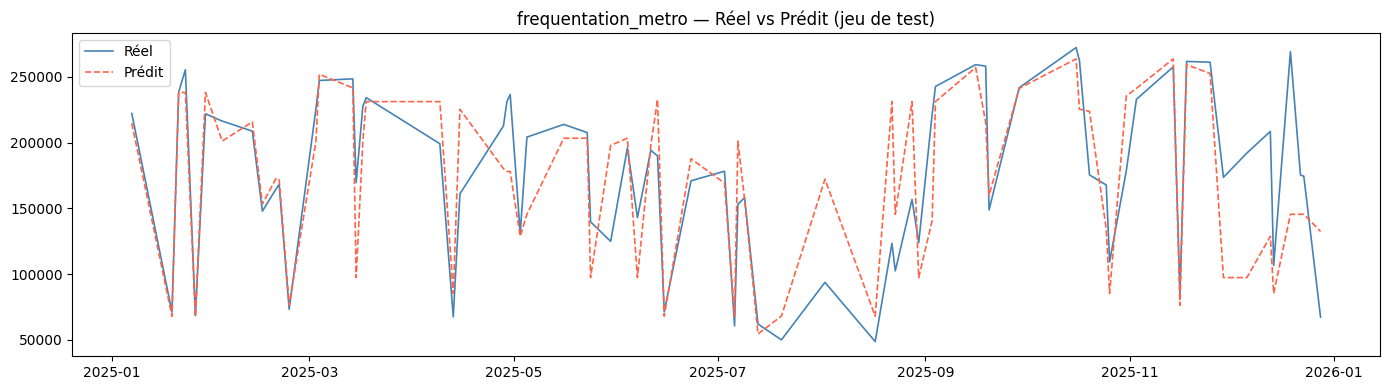

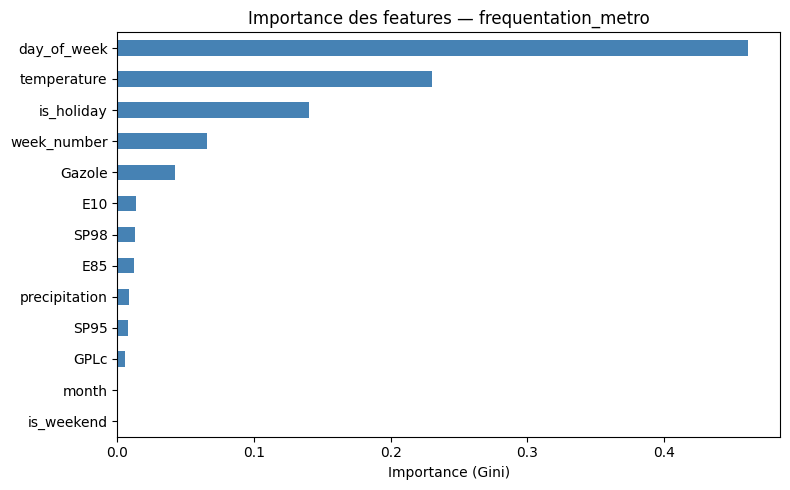


── Évaluation frequentation_bus ──────────────────
  MAE  :        9,221 voyageurs
  RMSE :       13,106 voyageurs
  R²   :       0.7760


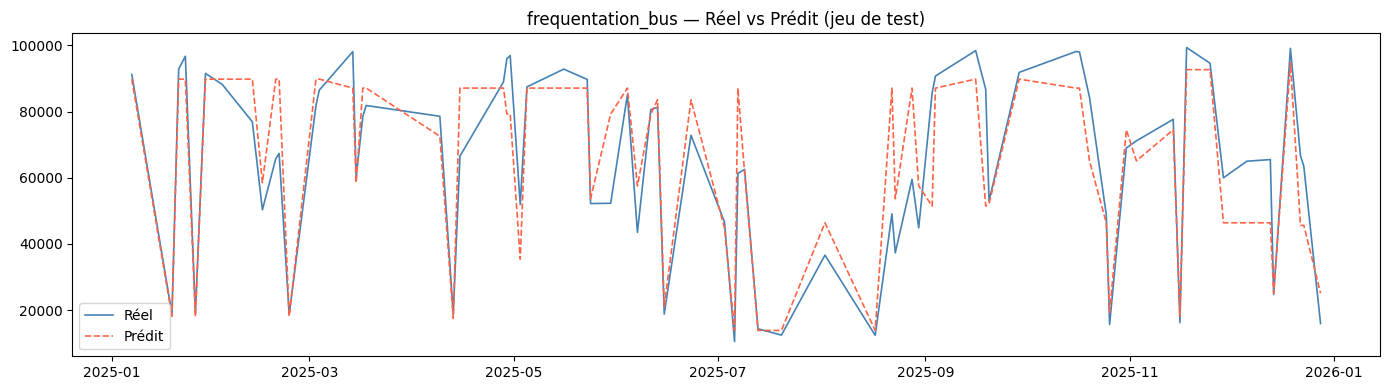

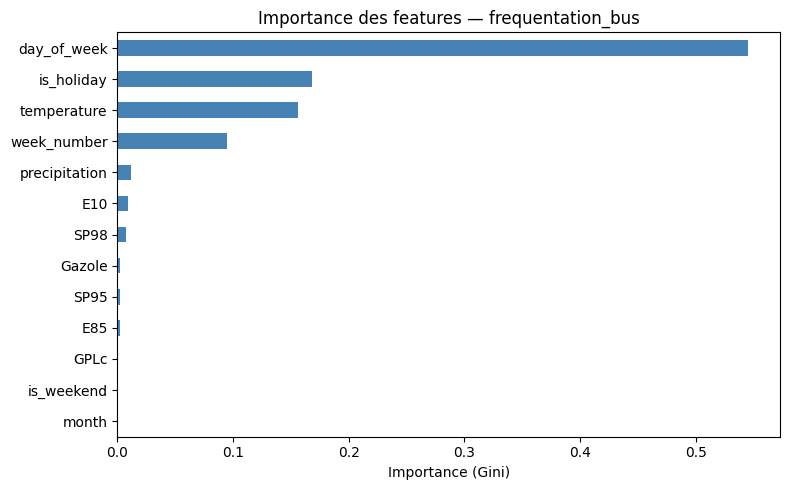

In [14]:
metrics_metro = evaluate_model(gs_metro, X_test, y_test_metro, 'frequentation_metro', df_test)
metrics_bus   = evaluate_model(gs_bus,   X_test, y_test_bus,   'frequentation_bus',   df_test)

In [15]:
compare_metrics(metrics_metro, metrics_bus)


── Récapitulatif des métriques ───────────────
           MAE     RMSE      R2
Metro  29412.0  41370.0  0.5781
Bus     9221.0  13106.0  0.7760


Le modèle **Bus** performe nettement mieux (R²=0.78) que le modèle **Métro** (R²=0.58).

Le bus est plus prévisible car sa fréquentation suit de manière plus régulière les patterns temporels encodés (jour de la semaine, vacances, férié).

Le métro présente une variabilité plus forte (le RMSE nettement supérieur à la MAE) trahit des **jours atypiques mal prédits** : grèves, incidents réseau, grands événements, qui ne sont pas capturés par les features disponibles.

Ces variables non observées constituent la principale piste d'amélioration du modèle métro.

PARTIE DECISION


Profondeur réelle de l'arbre : 14
Affichage limité à max_depth=3 pour la lisibilité.


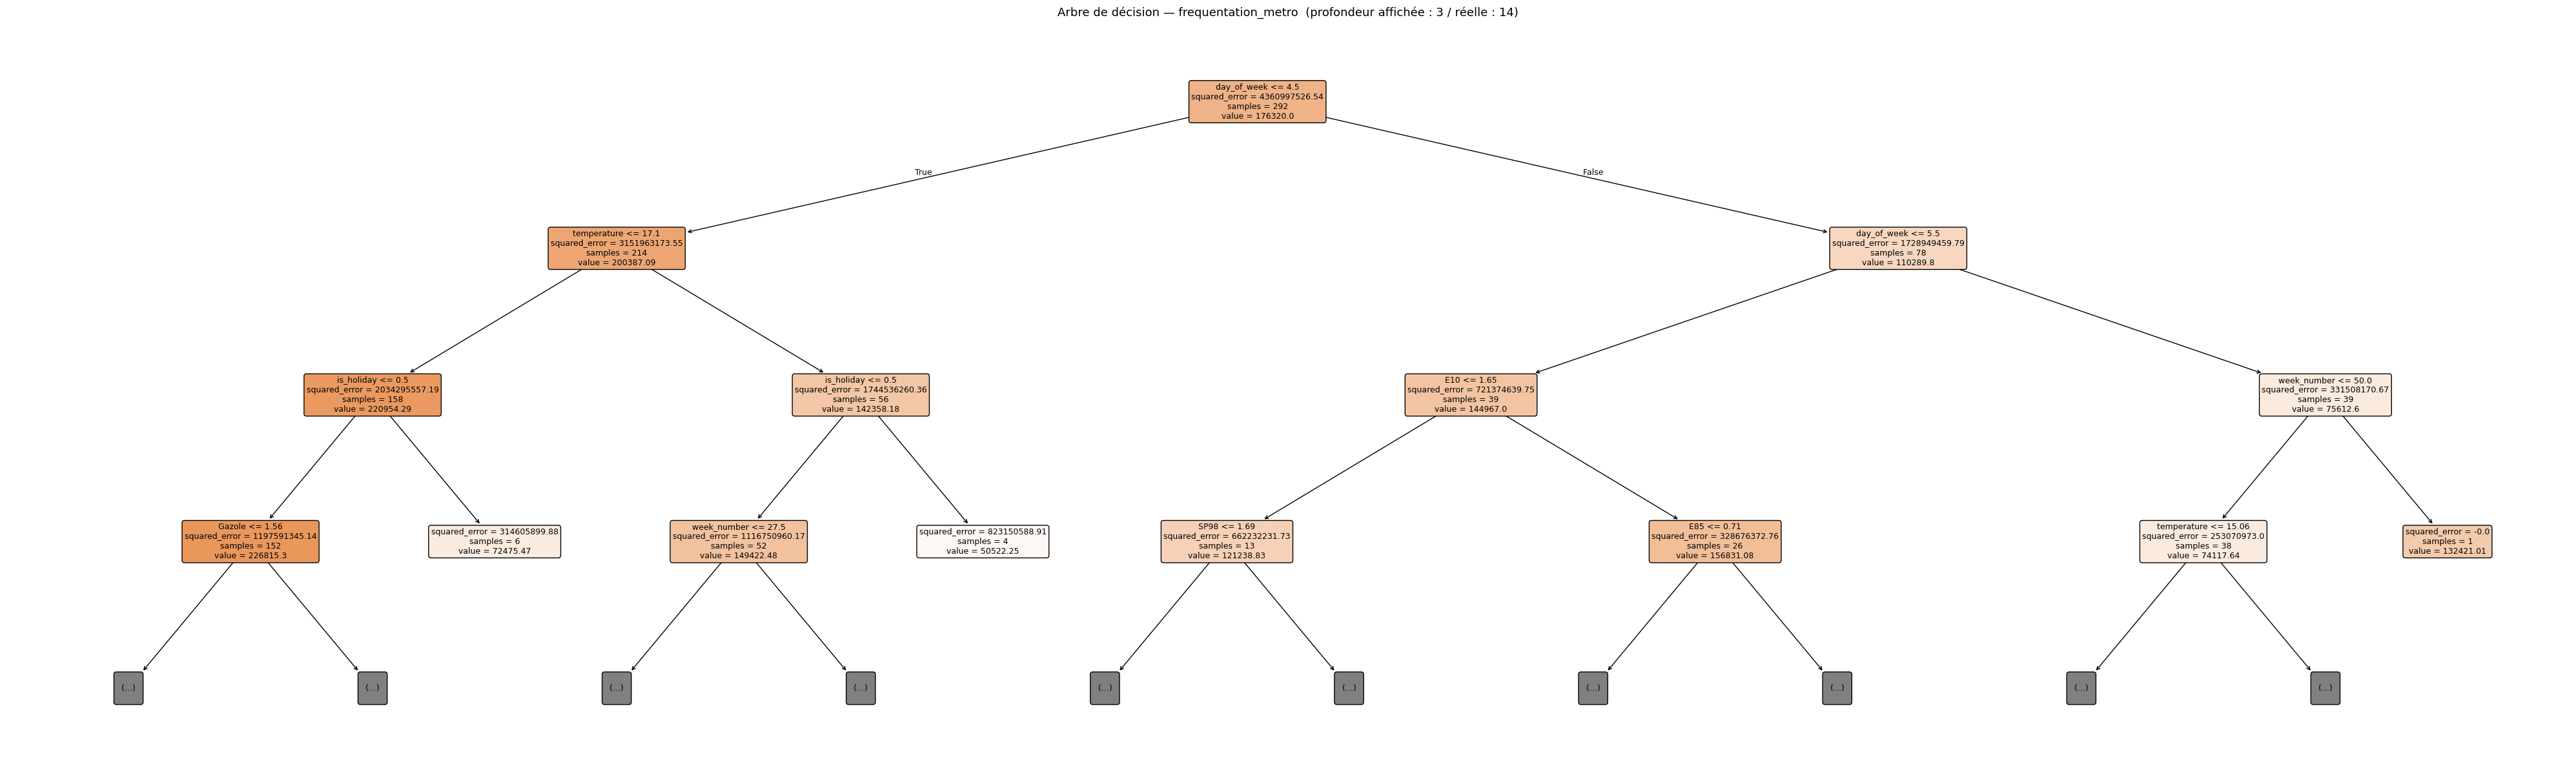

Profondeur réelle de l'arbre : 10
Affichage limité à max_depth=3 pour la lisibilité.


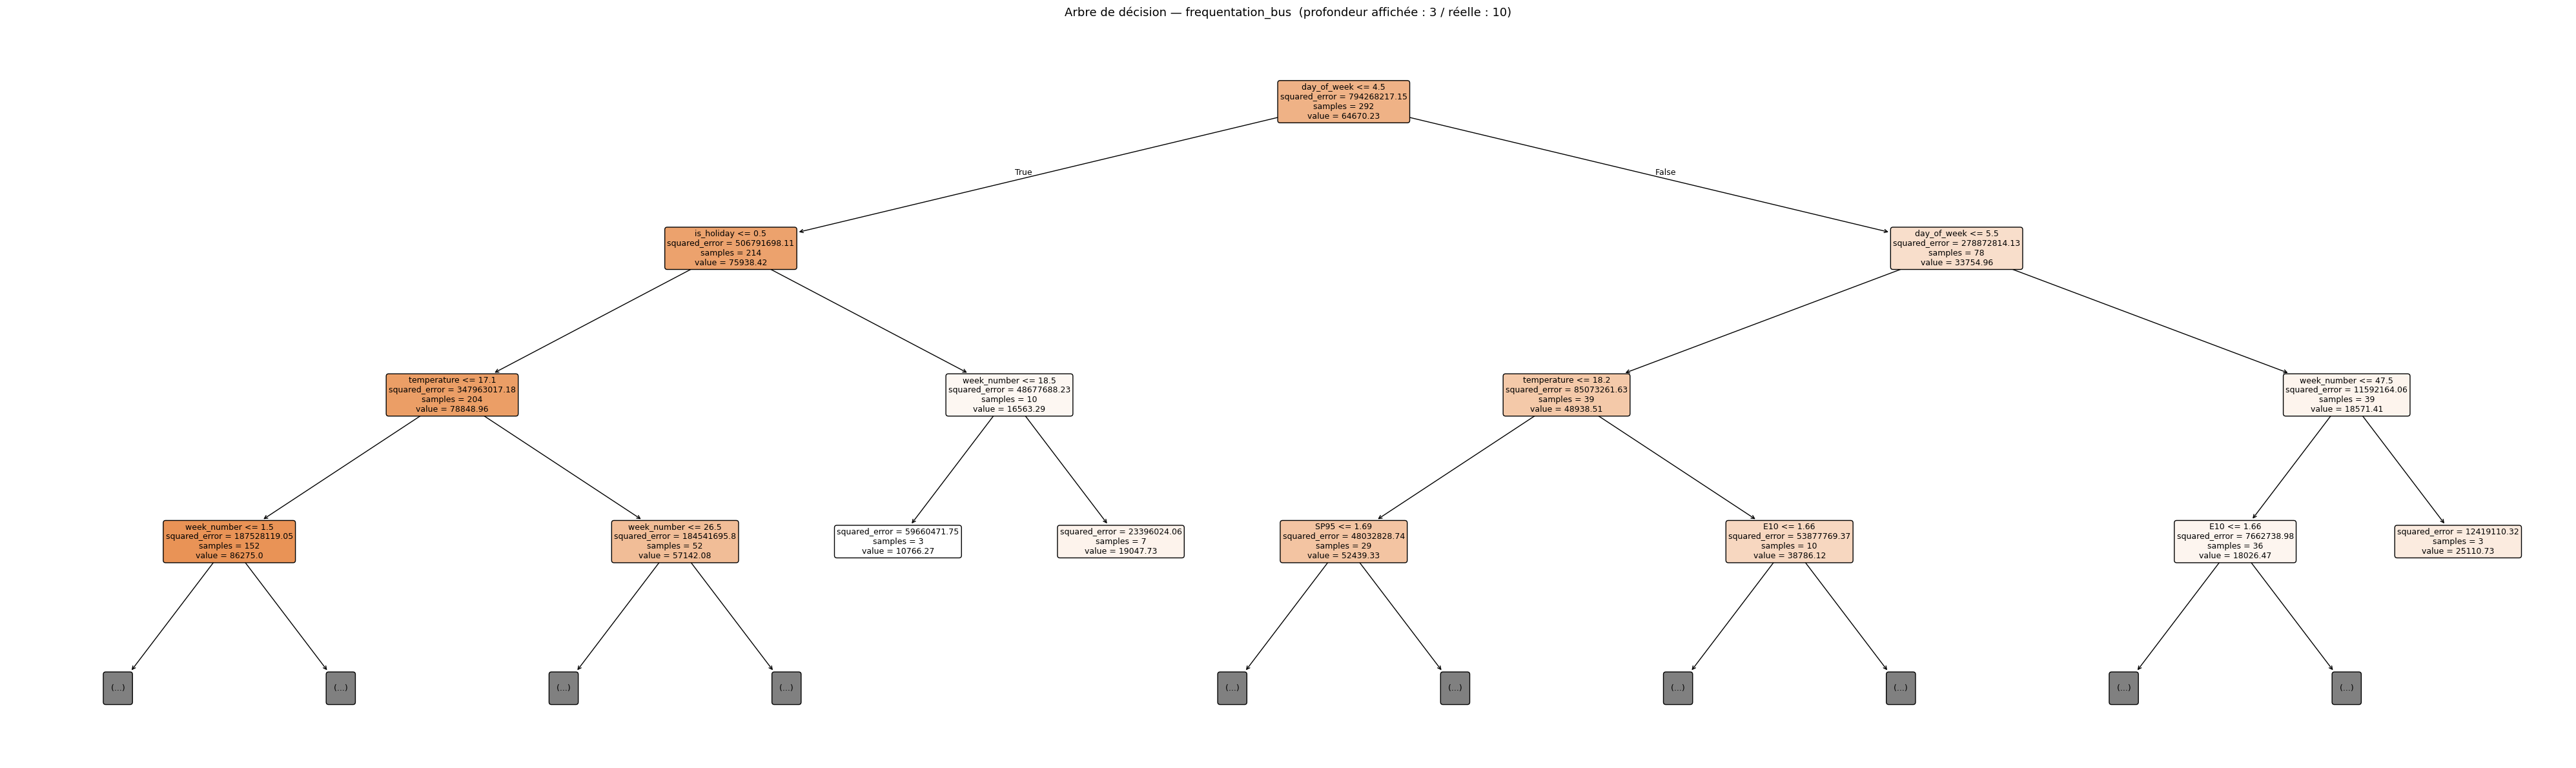

In [16]:
from src.regression import plot_decision_tree

# Arbre métro
plot_decision_tree(gs_metro, target_name='frequentation_metro', max_depth=3)

# Arbre bus
plot_decision_tree(gs_bus, target_name='frequentation_bus', max_depth=3)

## Partie 5 : Prédiction

Fonction finale de prédiction : à partir d'une date, des conditions météo et des prix carburant du jour sélectionné, le modèle retourne une estimation de la fréquentation.

Changer `ligne='metro'` en `ligne='bus'` pour obtenir la prédiction bus.

In [17]:
predict_frequentation(
    date          = '2026-06-15',
    temperature   = 22.0,
    precipitation = 0.0,
    E10           = 1.72,
    E85           = 0.79,
    GPLc          = 0.92,
    Gazole        = 1.65,
    SP95          = 1.75,
    SP98          = 1.82,
    ligne         = 'metro',
    model_metro   = gs_metro,
    model_bus     = gs_bus
)


Prédiction fréquentation metro le 2026-06-15 :
  Jour férié : non | Week-end : non
  → 178,030 voyageurs estimés


np.float64(178029.72415999998)

## Conclusion

Ce projet modélise la fréquentation des transports en commun (métro et bus) à partir de variables temporelles, météorologiques et de prix carburant sur l'année 2025.

L'analyse exploratoire a confirmé que les **variables temporelles** (jour de la semaine,
jours fériés, vacances) sont de loin les features les plus prédictives, devant la température et les carburants dont le signal reste faible à cette échelle.

Les résultats du modèle arbre de décision sont **corrects mais perfectibles** : le bus (R²=0.78) est bien modélisé, le métro (R²=0.58) souffre d'une variabilité non capturée : événements ponctuels, grèves, incidents réseau (absents des features).

### Limites principales

- **1 an de données seulement** : le modèle apprend les patterns de 2025 mais ne peut pas généraliser à d'autres années. Avec 3 à 5 ans de données, les tendances long terme (inflation carburant, évolution des habitudes) deviendraient exploitables.
- **Absence d'événements exceptionnels** : grèves, concerts, matchs, pannes,... : autant de pics non prédictibles avec les features actuelles.
- **Arbre de décision seul** : un modèle plus robuste (Random Forest, XGBoost) réduirait le risque de sur-apprentissage et améliorerait la généralisation.

### Pistes d'amélioration

- Enrichir avec des données d'événements (agenda culturel, sportif)
- Ajouter les vacances scolaires comme feature explicite
- Tester des modèles ensemblistes ou des approches de séries temporelles
- Accumuler les données sur plusieurs années pour gagner en robustesse